# LangChain: Memory

## Outline
* ConversationBufferMemory
* ConversationBufferWindowMemory
* ConversationTokenBufferMemory
* ConversationSummaryMemory

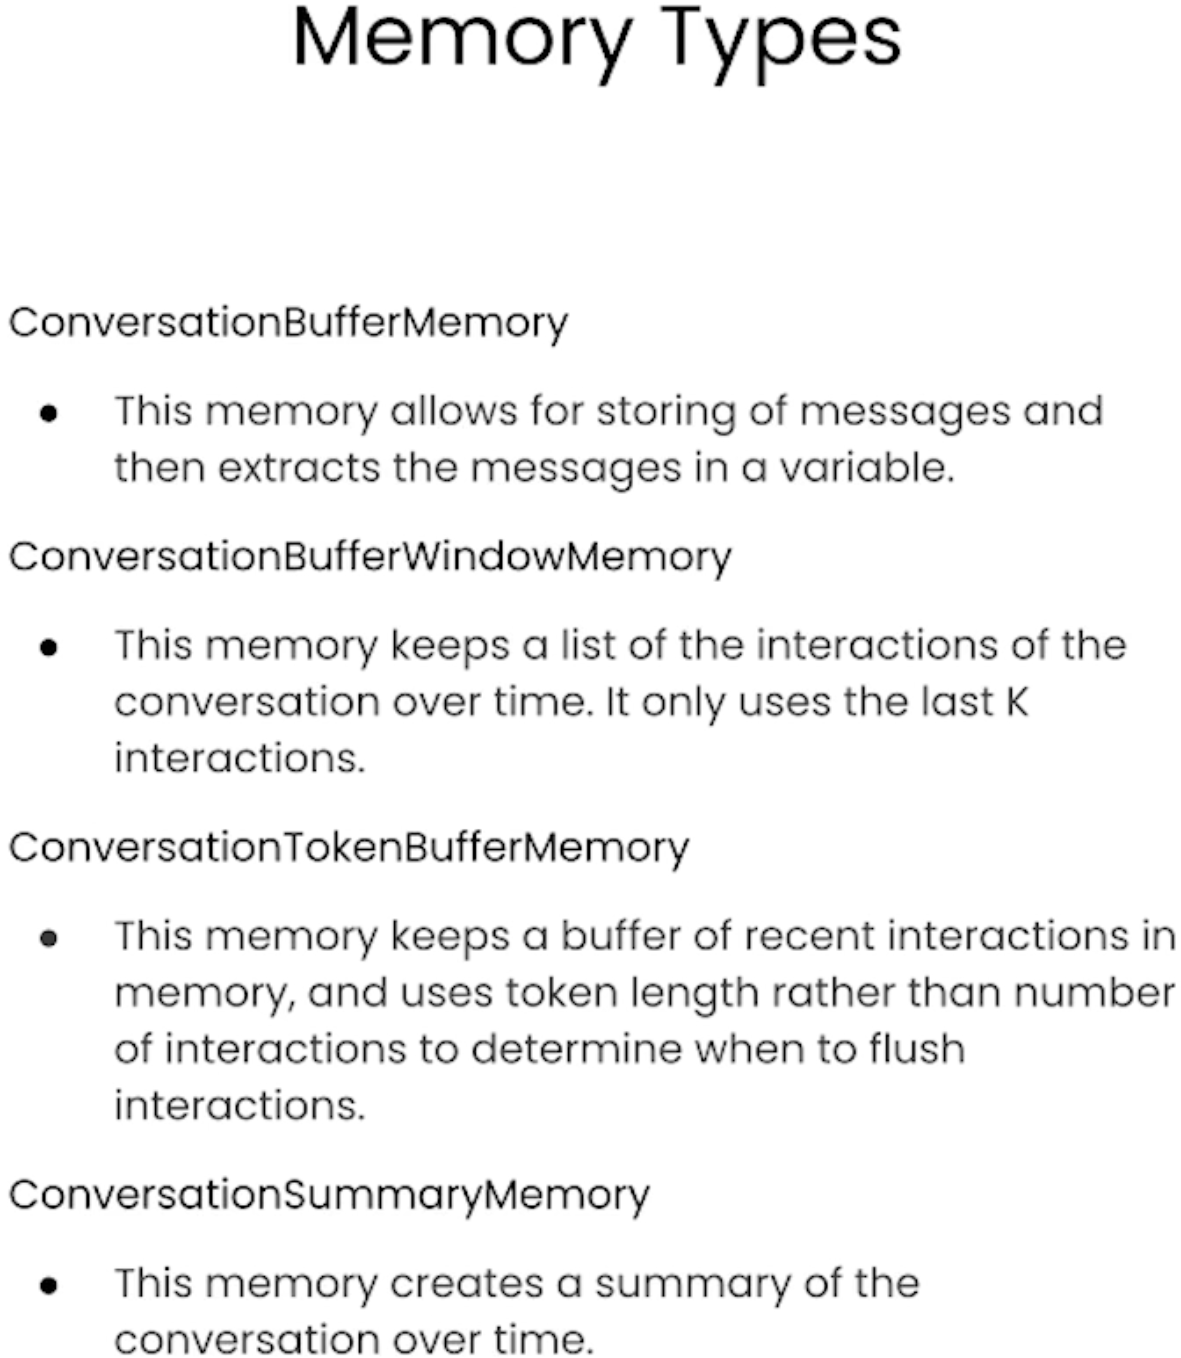

In [1]:
import os
from openai import OpenAI

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

client = OpenAI()

import warnings
warnings.filterwarnings('ignore')

In [2]:
llm_model = "gpt-3.5-turbo"

In [3]:
# pip install langchain-community

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage

In [5]:
llm = ChatOpenAI(temperature=0.0, model=llm_model)

from collections import deque
history = deque()

def conversation(user_input, verbose=False):
    history.append(HumanMessage(content=user_input))
    response = llm.invoke(history)
    history.append(AIMessage(content=response.content))
    
    if verbose:
        print(f"Human: {user_input}")
        print(f"AI: {response.content}\n")
        
    return response.content

In [6]:
conversation("Hi, my name is Andrey")

'Hello Andrey, nice to meet you! How can I assist you today?'

In [7]:
conversation("What is 1+1?")

'1 + 1 equals 2.'

In [8]:
conversation("What is my name?")

'Your name is Andrey.'

In [9]:
for msg in history:
    print(f"{'Human' if isinstance(msg, HumanMessage) else 'AI'}: {msg.content}")

Human: Hi, my name is Andrey
AI: Hello Andrey, nice to meet you! How can I assist you today?
Human: What is 1+1?
AI: 1 + 1 equals 2.
Human: What is my name?
AI: Your name is Andrey.


In [10]:
 {"history": history}

{'history': deque([HumanMessage(content='Hi, my name is Andrey', additional_kwargs={}, response_metadata={}),
        AIMessage(content='Hello Andrey, nice to meet you! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
        HumanMessage(content='What is 1+1?', additional_kwargs={}, response_metadata={}),
        AIMessage(content='1 + 1 equals 2.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
        HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}),
        AIMessage(content='Your name is Andrey.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])}

In [11]:
{"history": [{"type": type(msg).__name__, "content": msg.content} for msg in history]}

{'history': [{'type': 'HumanMessage', 'content': 'Hi, my name is Andrey'},
  {'type': 'AIMessage',
   'content': 'Hello Andrey, nice to meet you! How can I assist you today?'},
  {'type': 'HumanMessage', 'content': 'What is 1+1?'},
  {'type': 'AIMessage', 'content': '1 + 1 equals 2.'},
  {'type': 'HumanMessage', 'content': 'What is my name?'},
  {'type': 'AIMessage', 'content': 'Your name is Andrey.'}]}

In [12]:
history = deque() # clear history

In [13]:
history.append(HumanMessage(content="Hi"))
history.append(AIMessage(content="What's up"))

In [14]:
for msg in history:
    print(f"{'Human' if isinstance(msg, HumanMessage) else 'AI'}: {msg.content}")

Human: Hi
AI: What's up


In [15]:
{"history": history}

{'history': deque([HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
        AIMessage(content="What's up", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])}

In [16]:
history.append(HumanMessage(content="Not much, just hanging"))
history.append(AIMessage(content="Cool"))

In [17]:
{"history": history}

{'history': deque([HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
        AIMessage(content="What's up", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
        HumanMessage(content='Not much, just hanging', additional_kwargs={}, response_metadata={}),
        AIMessage(content='Cool', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])}

## ConversationBufferWindowMemory

In [18]:
class ConversationBufferWindowMemory:
    def __init__(self, k):
        self.k = k
        self.history = deque(maxlen= k * 2) # auto-evicts oldest when full

    def save_context(self, input_dict, output_dict):
        self.history.append(HumanMessage(content=input_dict["input"]))
        self.history.append(AIMessage(content=output_dict["output"]))

    def get_messages(self):
        return list(self.history)

In [19]:
memory = ConversationBufferWindowMemory(k=1)

In [20]:
memory.save_context({"input": "Hi"},
                    {"output": "What's up"})
memory.save_context({"input": "Not much, just hanging"},
                    {"output": "Cool"})

In [21]:
{"history": memory.get_messages()}

{'history': [HumanMessage(content='Not much, just hanging', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Cool', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

In [22]:
llm = ChatOpenAI(temperature=0.0, model=llm_model)
memory = ConversationBufferWindowMemory(k=1)

def conversation(input, verbose=False):
    messages = memory.get_messages() + [HumanMessage(content=input)]
    response = llm.invoke(messages)
    memory.save_context({"input": input}, {"output": response.content})
    if verbose:
        print(f"Human: {input}\nAI: {response.content}\n")
    return response.content

In [23]:
conversation("Hi, my name is Andrew")

'Hello Andrew, nice to meet you! How can I assist you today?'

In [24]:
conversation("What is 1+1?")

'1+1 equals 2.'

In [25]:
conversation("What is my name?")

"I'm sorry, I do not have access to personal information."

## ConversationTokenBufferMemory

In [26]:
# pip install tiktoken

In [27]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(temperature=0.0, model=llm_model)

In [28]:
import tiktoken
  
class ConversationTokenBufferMemory:
    def __init__(self, llm, max_token_limit):
        self.max_token_limit = max_token_limit
        self.history = deque()
        self.encoder = tiktoken.encoding_for_model(llm_model)
  
    def _count_tokens(self, text):
        return len(self.encoder.encode(text))

    def _total_tokens(self):
        return sum(self._count_tokens(m.content) for m in self.history)

    def save_context(self, input_dict, output_dict):
        self.history.append(HumanMessage(content=input_dict["input"]))
        self.history.append(AIMessage(content=output_dict["output"]))
        while self._total_tokens() > self.max_token_limit and len(self.history) > 2:
            self.history.popleft()
            self.history.popleft()
  
    def get_messages(self):
        return list(self.history)

memory = ConversationTokenBufferMemory(llm=llm, max_token_limit=50)
memory.save_context({"input": "AI is what?!"}, {"output": "Amazing!"})
memory.save_context({"input": "Backpropagation is what?"}, {"output": "Beautiful!"})
memory.save_context({"input": "Chatbots are what?"}, {"output": "Charming!"})

In [29]:
{"history": memory.get_messages()}

{'history': [HumanMessage(content='AI is what?!', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Amazing!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Backpropagation is what?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Beautiful!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Chatbots are what?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Charming!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

In [30]:
memory = ConversationTokenBufferMemory(llm=llm, max_token_limit=20)
memory.save_context({"input": "AI is what?!"},
                    {"output": "Amazing!"})
memory.save_context({"input": "Backpropagation is what?"},
                    {"output": "Beautiful!"})
memory.save_context({"input": "Chatbots are what?"}, 
                    {"output": "Charming!"})

In [31]:
{"history": memory.get_messages()}

{'history': [HumanMessage(content='Backpropagation is what?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Beautiful!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Chatbots are what?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Charming!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

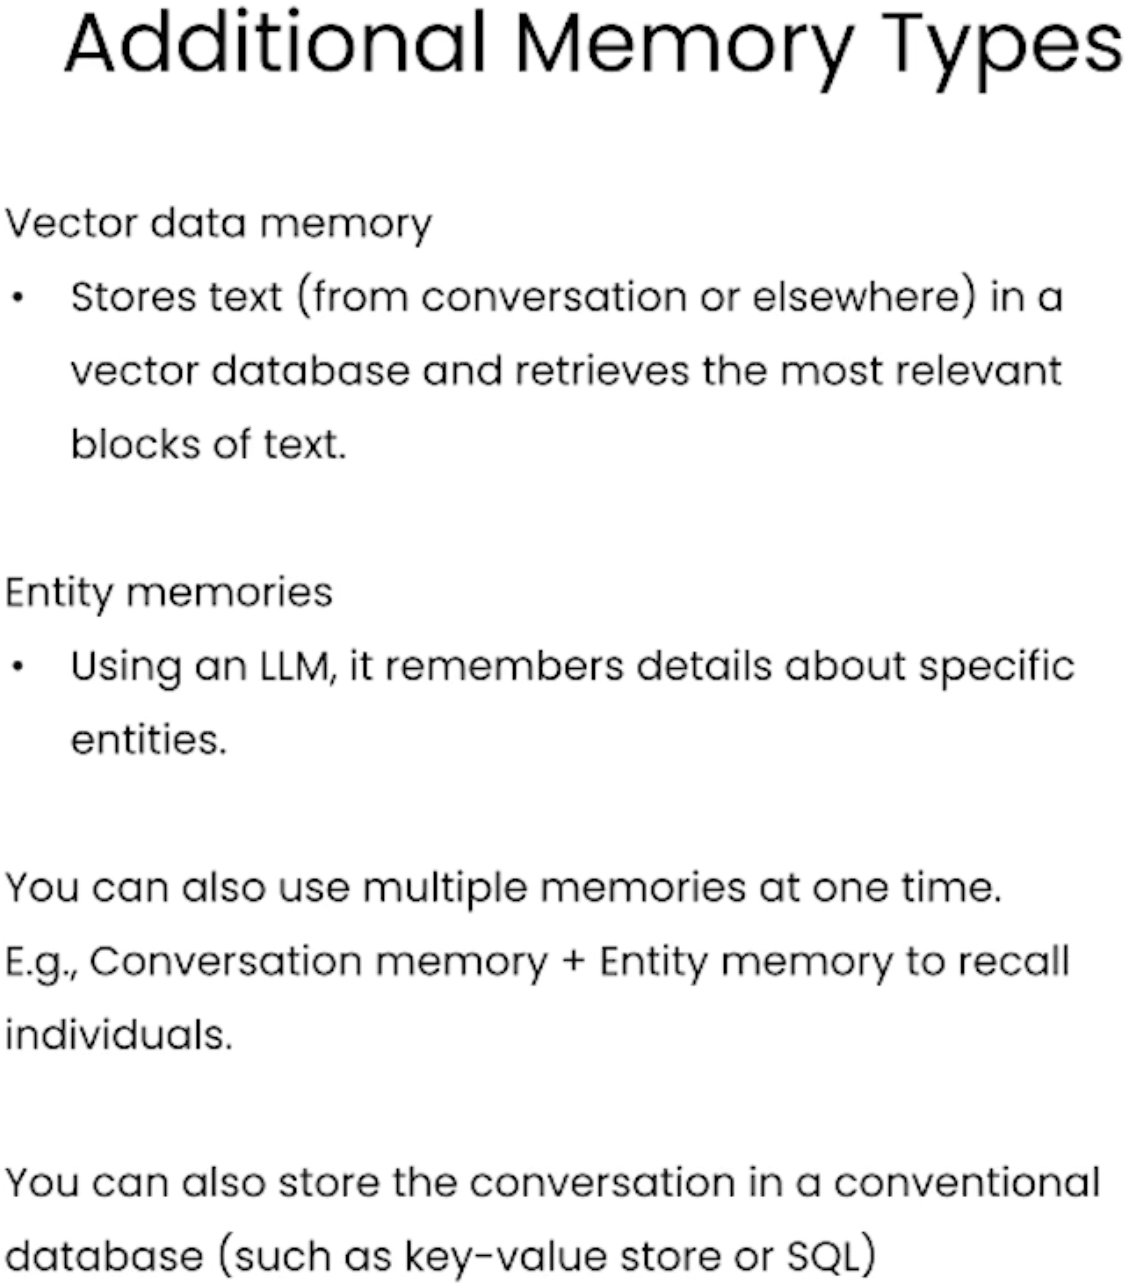

## ConversationSummaryMemory

In [32]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

class ConversationSummaryBufferMemory:
    def __init__(self, llm, max_token_limit):
        self.llm = llm
        self.max_token_limit = max_token_limit
        self.history = deque()
        self.summary = ""
        self.encoder = tiktoken.encoding_for_model(llm_model)

    def _count_tokens(self, text):
        return len(self.encoder.encode(text))

    def _total_tokens(self):
        return sum(self._count_tokens(m.content) for m in self.history)

    def _summarize(self):
        messages_text = "\n".join(
            f"{'Human' if isinstance(m, HumanMessage) else 'AI'}: {m.content}"
            for m in self.history
        )
        prompt = f"Summarize this conversation:\n{messages_text}"
        response = self.llm.invoke([HumanMessage(content=prompt)])
        return response.content
  
    def save_context(self, input_dict, output_dict):
        self.history.append(HumanMessage(content=input_dict["input"]))
        self.history.append(AIMessage(content=output_dict["output"]))
        if self._total_tokens() > self.max_token_limit:
            self.summary = self._summarize()
            self.history = deque()
  
    def get_messages(self):
        messages = []
        if self.summary:
            messages.append(SystemMessage(content=f"Summary: {self.summary}"))
        return messages + list(self.history)
  
    def load_memory_variables(self, _):
        return {"history": self.get_messages()}

In [33]:
# create a long string
schedule = "There is a meeting at 8am with your product team. \
You will need your powerpoint presentation prepared. \
9am-12pm have time to work on your LangChain \
project which will go quickly because Langchain is such a powerful tool. \
At Noon, lunch at the italian resturant with a customer who is driving \
from over an hour away to meet you to understand the latest in AI. \
Be sure to bring your laptop to show the latest LLM demo."

memory = ConversationSummaryBufferMemory(llm=llm, max_token_limit=100)
memory.save_context({"input": "Hello"}, {"output": "What's up"})
memory.save_context({"input": "Not much, just hanging"},
                    {"output": "Cool"})
memory.save_context({"input": "What is on the schedule today?"}, 
                    {"output": f"{schedule}"})

In [34]:
memory.load_memory_variables({})

{'history': [SystemMessage(content='Summary: The AI informs the human of their schedule for the day, including a meeting with their product team at 8am, work on their LangChain project from 9am-12pm, and a lunch meeting with a customer at Noon to discuss the latest in AI. The human is reminded to bring their laptop to show a demo during the lunch meeting.', additional_kwargs={}, response_metadata={})]}

In [35]:
def conversation(input, verbose=False):
    messages = memory.get_messages() + [HumanMessage(content=input)]
    response = llm.invoke(messages)
    memory.save_context({"input": input}, {"output": response.content})
    if verbose:
        print(f"Human: {input}\nAI: {response.content}\n")
    return response.content

In [36]:
conversation("What would be a good demo to show?")

'For the lunch meeting with the customer to discuss the latest in AI, a good demo to show would be a live demonstration of the LangChain project you have been working on from 9am to 12pm. This will give the customer a firsthand look at the capabilities and potential of the project, showcasing how AI is being utilized in language processing and blockchain technology. Additionally, you could highlight any recent advancements or features that have been implemented since the last meeting to demonstrate progress and innovation in the field. This interactive demo will not only engage the customer but also provide a tangible example of the work you and your team have been doing.'

In [37]:
memory.load_memory_variables({})

{'history': [SystemMessage(content='Summary: The AI suggests showcasing a live demonstration of the LangChain project during a lunch meeting with a customer to discuss the latest in AI. This will give the customer a firsthand look at the capabilities of the project and demonstrate progress and innovation in the field. The interactive demo will engage the customer and highlight the work of the team.', additional_kwargs={}, response_metadata={})]}